|                      | Blob        | Data Lake            |
| -------------------- | ----------- | -------------------- |
| Purpose              | Store files | Store analytics data |
| Folder hierarchy     | Limited     | Real folders         |
| Big data support     | Basic       | Strong               |
| Data processing      | Limited     | Designed for it      |
| ML pipelines         | Possible    | Preferred            |
| Raw→Processed layers | Manual      | Natural              |


# Interview Answer

Question:

Why did you choose Azure Data Lake?

Good answer:

We needed layered storage for raw, validated and processed datasets, better separation of concerns, reproducibility and support for scalable ML workflows

Azure Data Lake exists because ML/Analytics systems need:
Structured storage
+
Data lifecycle
+
Large-scale processing
+
Layered architecture

# Data Ingestion Architetcure

Source
↓
Ingestion
↓
Raw/ sales.csv (Original untouched)
↓ 
Validated (Schema approved)
↓
Processed (Cleaned + merged)
↓
Features (ML-ready)
↓ 
Models (Artifacts)

What is a Lag Feature?
A lag feature means: Past value used as input for predicting future value.
Lag features convert time behavior into machine learning features
Without lag features: XGBoost , LightGBM cannot understand time naturally.

Interview Question?
Why are lag features important?
Lag features help machine learning models capture temporal dependencies by using historical values as predictive signals for future forecasting.

Important Production Insight

Lag features MUST be:

✅ sorted by time
✅ grouped correctly
✅ leakage-free

# Temporal Dependency
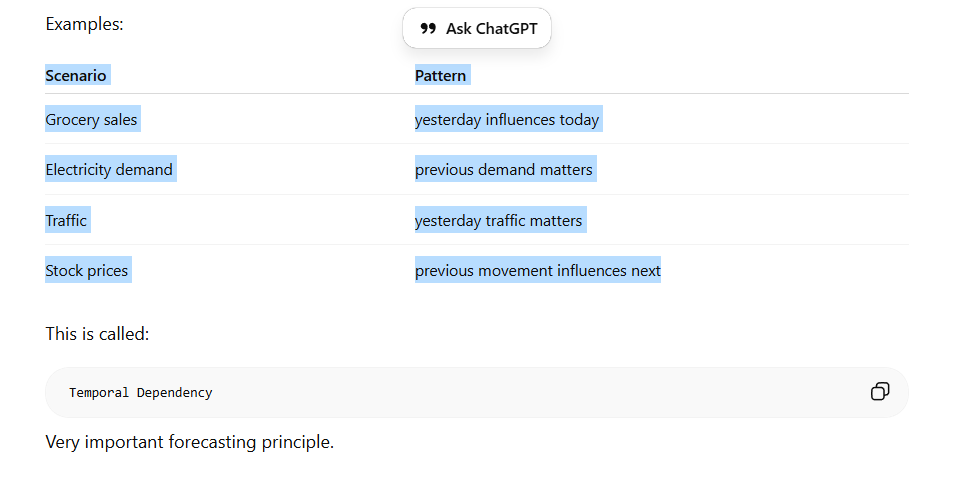

lookback window
semantic missingvallue

Why use both lag and rolling features?

Good answer:

Lag features capture specific historical observations, while rolling features capture aggregated historical behavior such as trends and volatility.

What is wm_yr_wk in M5?

Good answer:

wm_yr_wk is Walmart's retail week identifier. It links calendar dates to weekly business information such as pricing. Since sell_prices.csv is maintained at weekly granularity, we use wm_yr_wk together with item_id and store_id to join pricing data with sales data.

If interviewer asks:

Why not use random train-test split for forecasting?

Strong answer:

Time-series observations are temporally dependent. Random shuffling leaks future information into training data and produces unrealistically optimistic performance estimates.

Final Project Roadmap
Phase 1 — Data Engineering ✅
✅ Azure Data Lake
✅ Data Ingestion
✅ Schema Validation
✅ Missing Value Validation
✅ Outlier Validation
✅ Great Expectations
Phase 2 — Feature Engineering ✅
✅ Reshape (Wide → Long)
✅ Calendar Join
✅ Lag Features
✅ Rolling Features
✅ Price Join
✅ Price Features

Phase 3 — Machine Learning Forecasting
Step 3.1 - Time Series Split

Last 28 days:

Train
↓
Test
S
tep 3.2 - Feature Selection

Keep:

lag features
rolling features
price features
calendar features

Drop:

id
date
Step 3.3 - Categorical Encoding

Target Encoding: item_id

Label Encoding:

store_id
state_id
dept_id
cat_id
Step 3.4
LightGBM Baseline

This becomes our primary production model.

Why?

Fast
Scalable
Handles millions of rows
Used heavily in retail forecasting
Step 3.5
Model Evaluation

Metrics:

MAE
RMSE
MAPE

And later:

WRMSSE

(the official M5 metric)

Phase 4 — Classical Forecasting

Now we compare ML vs Classical Forecasting.

ARIMA

For selected products.

Learn:

p
d
q
stationarity
ACF
PACF
SARIMA

Add:

seasonality

Learn:

P
D
Q
s
Prophet

Add:

trend
seasonality
holiday effects

using the Walmart events.

Phase 5 — Comparison Study

For the same products:

Model	MAE	RMSE
ARIMA	?	?
SARIMA	?	?
Prophet	?	?
LightGBM	?	?

This becomes an excellent portfolio section.

Phase 6 — Advanced Forecasting

If time permits:

XGBoost
CatBoost

and maybe

LSTM
TFT

for learning purposes.

Phase 7 — Productionization
Azure ML
Model Registry
Batch Inference
Streamlit Dashboard

In [2]:
import sklearn
print(sklearn.__version__)

1.9.0


Why doesn't MLflow store models in SQLite?

A strong answer:

SQLite (or another tracking database) is optimized for structured metadata such as experiments, runs, parameters, and metrics. Models, plots, and datasets can be hundreds of megabytes or even gigabytes in size, so MLflow stores them separately in an artifact store such as a local filesystem, Azure Blob Storage, or Amazon S3. This separation improves scalability and performance.

                 MLflow

             +------------------+
             |  Tracking Store  |
             |   (SQLite DB)    |
             +------------------+
                      |
          --------------------------
          |                        |
   Parameters                Metrics
   Experiment               Run IDs
   Tags                     Status

                      +

             +------------------+
             | Artifact Store   |
             | (mlruns / Azure) |
             +------------------+
                      |
             Models
             Images
             CSV Files
             SHAP

How do you avoid manually logging dozens of hyperparameters?

A strong answer:

"Since most Scikit-learn compatible models expose get_params(), I use that to automatically retrieve the model configuration and log it with mlflow.log_params(). This avoids duplication and ensures the logged configuration exactly matches the trained model."

That answer demonstrates both MLflow knowledge and good software engineering practices.

Why did you optimize RMSE instead of MAE?

A strong answer is:

"I tracked both MAE and RMSE, but I selected RMSE as the primary optimization metric because it penalizes large forecasting errors more heavily. In demand forecasting, a few large under-forecasting or over-forecasting errors can have a much greater business impact than many small errors, such as stock-outs, excess inventory, or increased holding costs. MAE remained useful as a complementary metric because it is easier to interpret in the original units."

# Light GBM

How does LightGBM handle categorical features?

A good answer is:

"LightGBM does not one-hot encode categorical features internally. For categorical splits, it computes statistics for each category (such as average target values for regression), orders the categories by those statistics, and then searches for the best split along that ordering. This avoids evaluating every possible grouping of categories, making it efficient even with high-cardinality features

Why do we import tune instead of ray?

A good answer is:

Ray is a distributed computing framework with multiple modules. ray.tune is the module specifically designed for hyperparameter tuning and experiment management. It provides abstractions like Tuner, TuneConfig, param_space, and tune.report(), while Ray Core provides distributed execution primitives such as @ray.remote and ray.get().

What is ray.core?

You already learned this.

It is responsible for:

ray.init()
@ray.remote
ray.get()
ObjectRef
Workers
Distributed execution

It knows nothing about Machine Learning.

It simply executes Python functions.

What is OptunaSearch?

Its responsibility is:

Generate the next configuration (hyperparameters) by applying Optuna's Bayesian Optimization algorithm over the defined param_space.

Because Optuna doesn't generate one hyperparameter at a time.

It generates an entire configuration.

Example:

{
    "learning_rate": 0.042,
    "num_leaves": 37,
    "max_depth": 6,
    "min_child_samples": 18
}

This entire dictionary is one configuration (or one trial).

It only does:

Generate Configuration

↓

Return Configuration

That's all.

Who trains the model?

Our trainable() function.

OptunaSearch
      │
Generate Config
      │
      ▼
trainable(config)
      │
      ▼
LightGBMTrainingEngine

Let's compare the components
Component	Responsibility
param_space	Defines what values are allowed
OptunaSearch	Chooses the next configuration using Bayesian Optimization
trainable()	Trains the model
LightGBMTrainingEngine	Builds the model, evaluates it, returns metrics
Ray	Executes trials in parallel

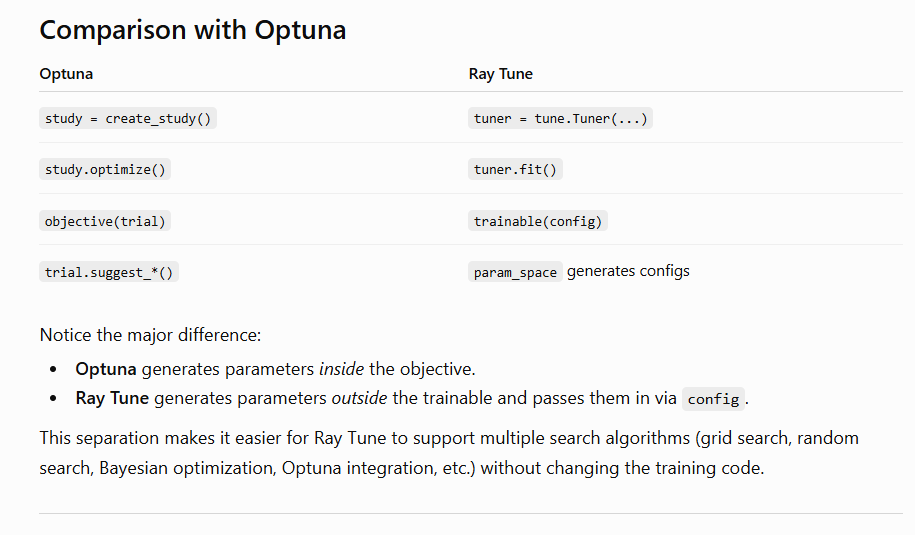
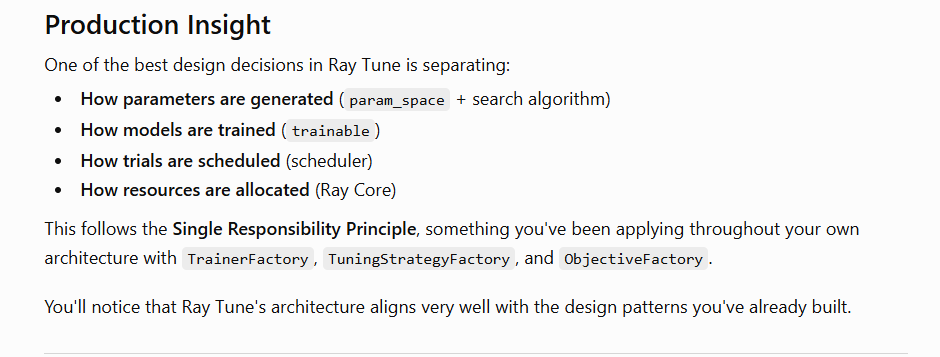

In [ ]:
| Hyperparameter Type                                                  | Ray Tune Distribution                   |
| -------------------------------------------------------------------- | --------------------------------------- |
| Continuous numeric (e.g., `learning_rate`, `subsample`, `reg_alpha`) | `tune.uniform()` or `tune.loguniform()` |
| Integer numeric (e.g., `max_depth`, `num_leaves`, `n_estimators`)    | `tune.randint()` or `tune.qrandint()`   |
| Categorical (e.g., `boosting_type`, `grow_policy`)                   | `tune.choice()`                         |


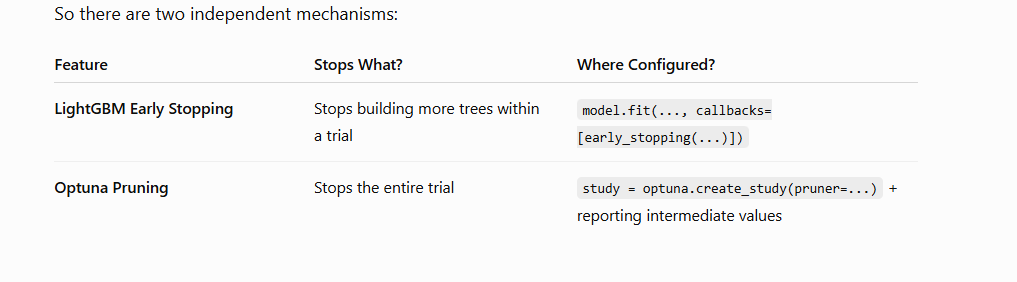

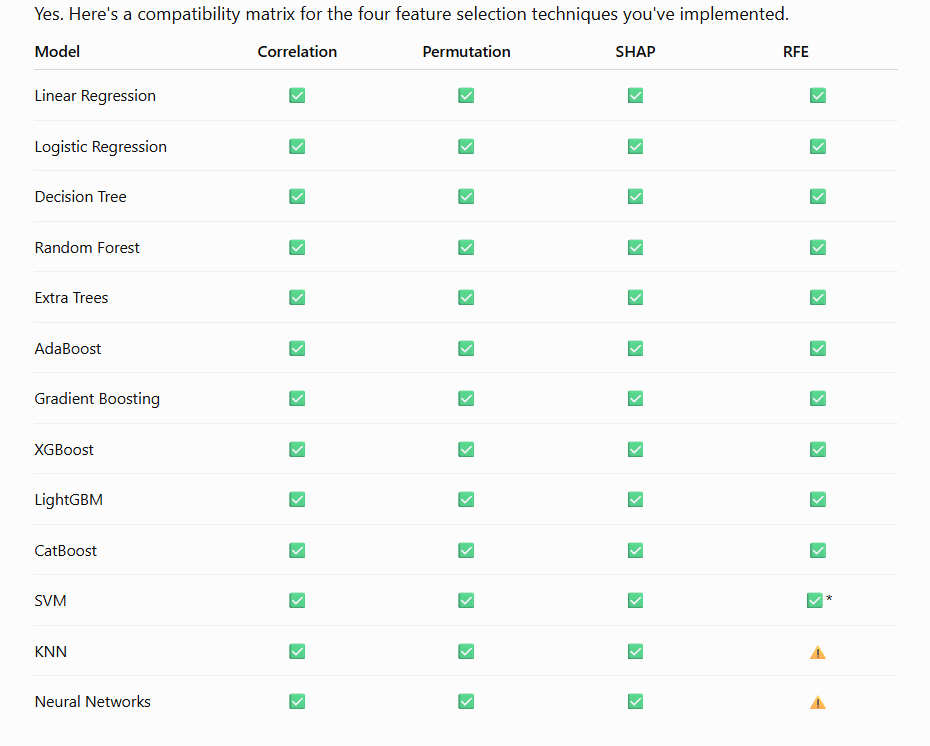
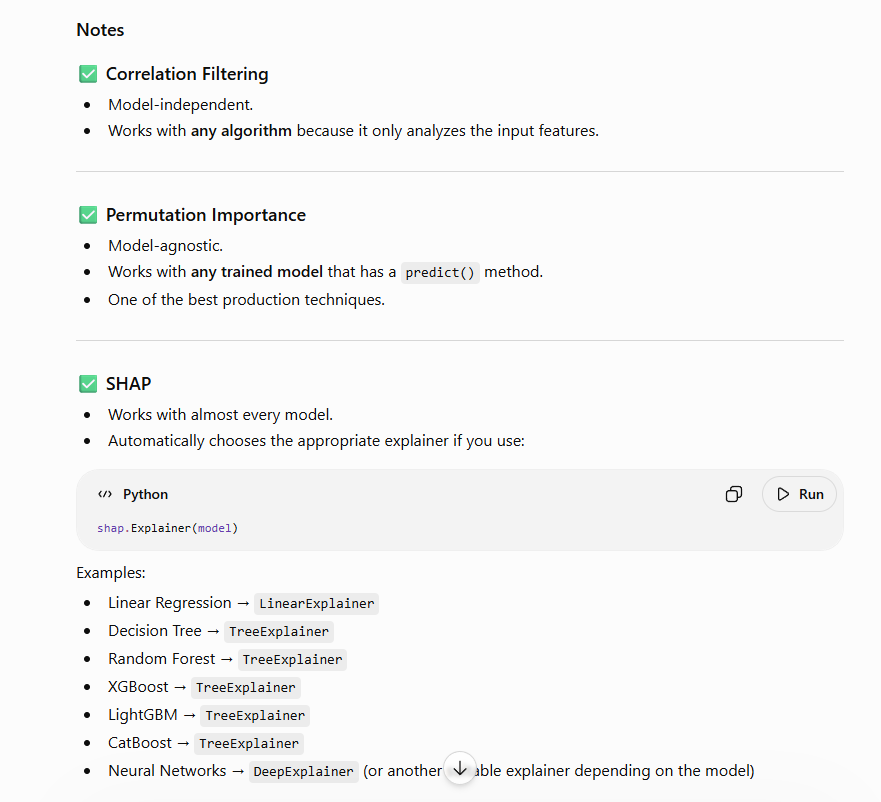
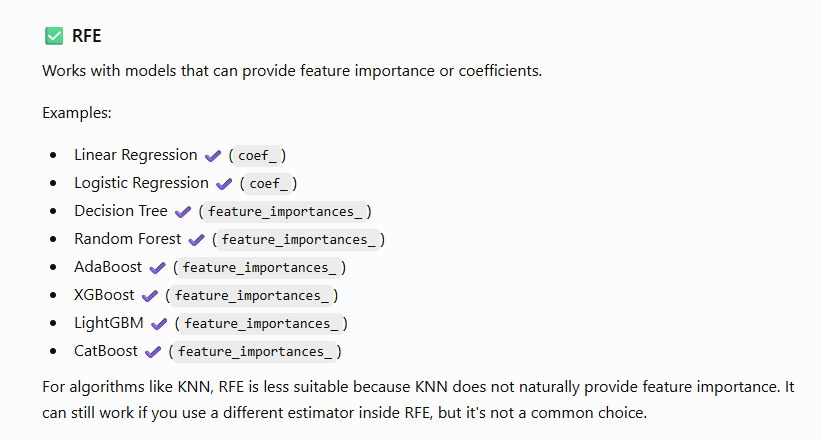
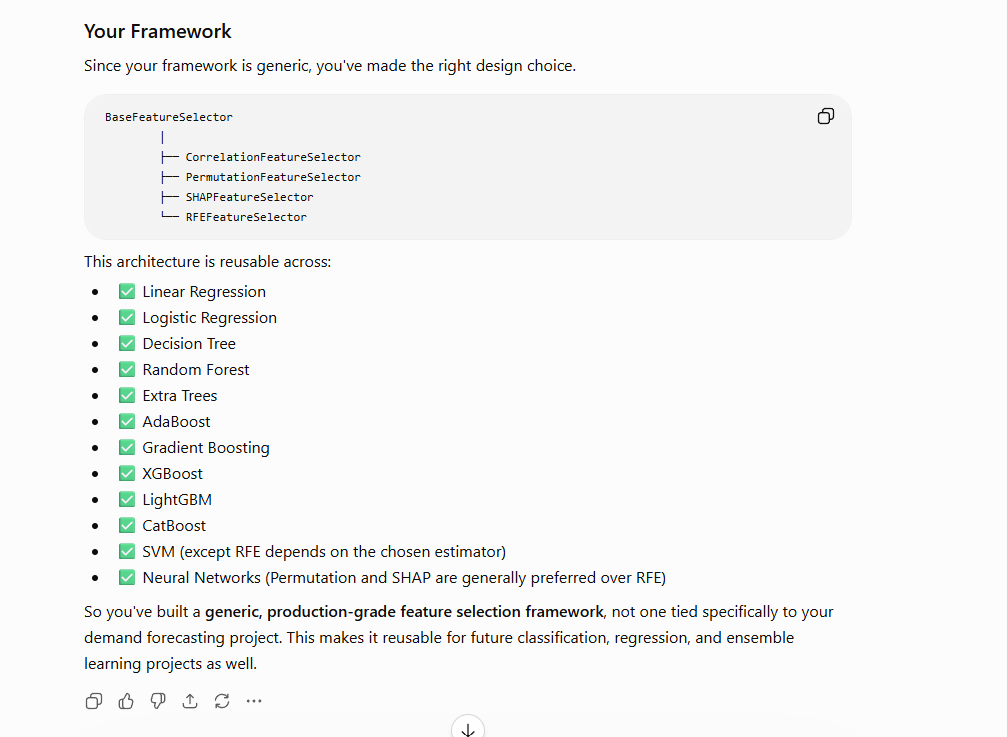

Important Feature Engineering Lesson

Not all missing values are errors.

Example:

Feature	Missing Meaning
event_name	no event
promotion_code	no promotion
holiday	normal day

This is called:

semantic missingness

Very important ML concept.

Q2 — Why multiple lag periods?

This is VERY important.

Different lag periods capture different temporal behaviors.

Examples:

Lag	Meaning
lag_1	yesterday pattern
lag_7	weekly pattern
lag_28	monthly pattern

Real Example

Suppose:

Ice cream sales

may follow:

weekend spikes

Then:

lag_7

becomes very useful because:

last Saturday
→ predicts this Saturday

Another Example

Monthly purchasing cycles:

salary cycles
inventory cycles
billing cycles

may appear in:

lag_28
lag_30

Very important forecasting insight.

Very Important Understanding

Lag features convert:

time behavior

into:

machine learning features

Without lag features:

XGBoost
LightGBM

cannot understand time naturally.

This is HUGE.

Important Interview Explanation

If interviewer asks:

Why are lag features important?

Good answer:

Lag features help machine learning models capture temporal dependencies by using historical values as predictive signals for future forecastin
Important Production Insight

Lag features MUST be:

✅ sorted by time
✅ grouped correctly
✅ leakage-free

Otherwise forecasts become wrong.

We’ll understand leakage soon. That is a critical AI Engineer concept.

Important Production Concept — Cold Start Window

Beginning rows cannot create lag features because:

insufficient history

This is called:

lookback window

Very common forecasting concept.

Rolling Window Features

This is another VERY important forecasting concept.

Examples:

7-day moving average
30-day rolling mean
rolling standard deviation

These help model understand:

✅ trend
✅ stability
✅ volatility
✅ seasonality

So rolling captures: overall trend . while lag captures: specific past point

Why Industries Love Rolling Features

Rolling features capture:

Trend
Demand increasing?
Demand decreasing?
Stability
Stable product?
Highly variable product?
Volatility

Using:

rolling_std we can understand:

Predictable demand
vs
Unpredictable demand

Common Forecasting Features

Most retail forecasting systems use:

Feature	Meaning
rolling_mean_7	Weekly trend
rolling_mean_28	Monthly trend
rolling_std_7	Weekly volatility
rolling_max_7	Weekly peak
rolling_min_7	Weekly minimum

Important Interview Question

Interviewer:

Why use both lag and rolling features?

Good answer:

Lag features capture specific historical observations, while rolling features capture aggregated historical behavior such as trends and volatility.

Very strong answer.

If you were documenting this project, you could write something like:

"After merging the sales and price datasets, 32,037 rows (0.29% of the data) contained missing sell_price values. Analysis showed that all of these rows had sales = 0, indicating no recorded transactions. These rows were removed to avoid imputing artificial prices while preserving data quality

In [ ]:
{"asctime": "2026-07-31 03:14:23,149", "levelname": "INFO", "name": "root", "message": "Train_data_shape_post_dropping_columns, ((8546641, 24), (8546641, 1))"}
{"asctime": "2026-07-31 03:14:23,149", "levelname": "INFO", "name": "root", "message": "Test_data_shape_post_dropping_columns, ((853720, 24), (853720, 1))"}
{"asctime": "2026-07-31 03:14:23,149", "levelname": "INFO", "name": "root", "message": "Validation_data_shape_post_dropping_columns,((853720, 24), (853720, 1))"}

"Can we use early stopping with LightGBM, XGBoost and CatBoost?"

A good answer is:

"Yes. All three algorithms natively support model-level early stopping. However, whether I can use it depends on the hyperparameter tuning framework. In frameworks like Optuna or a custom Ray Tune trainable, where I control the training loop and validation data, I can use early stopping directly. With scikit-learn's GridSearchCV and RandomizedSearchCV, it's less straightforward because those frameworks manage the cross-validation process internally."

Since you're supporting LightGBM, XGBoost, and CatBoost, I recommend creating a small table for yourself:

Parameter	LightGBM	XGBoost 3.x	CatBoost
eval_metric	fit()	Constructor	fit()
early_stopping	callbacks in fit()	Constructor (early_stopping_rounds)	fit() (early_stopping_rounds)
eval_set	fit()	fit()	fit()

Summary
Algorithm	Native categorical setting
XGBoost	XGBRegressor(enable_categorical=True) (constructor)
LightGBM	Convert columns to category dtype (optionally pass categorical_feature to fit())
CatBoost	CatBoostRegressor(...).fit(..., cat_features=...) or specify cat_features when constructing the model

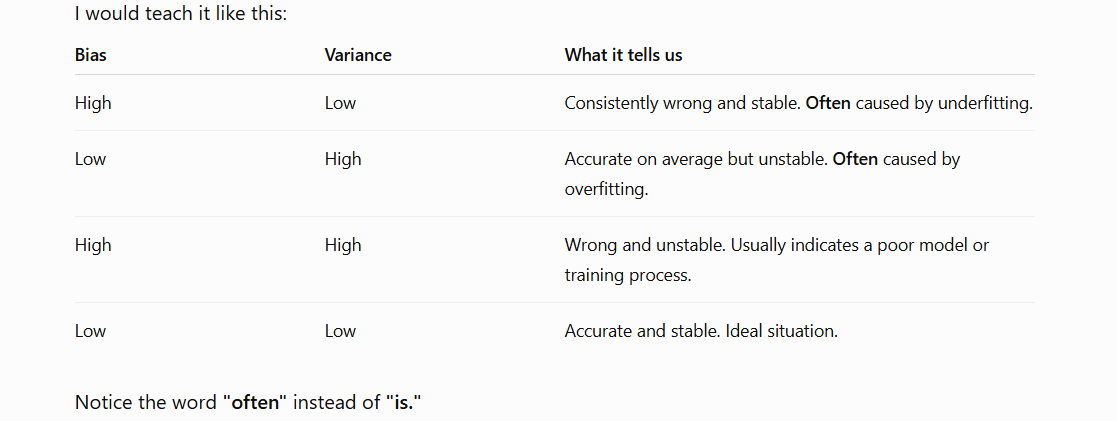

Bias measures systematic error:

Is the model's average prediction consistently away from the true value?

The One Sentence You Should Remember

Whenever you hear variance, think:

"If I train my algorithm on a different sample of the training data, how much will the prediction change for the same input?"

There are two moving parts:

🔄 Training dataset changes
📌 Prediction input remains fixed

Bias = systematic mistake → averaging usually doesn't fix it.
Variance = random fluctuations → averaging smooths them out.

This distinction is the heart of why ensembles work.
3. Why does averaging multiple diverse models reduce variance but not necessarily eliminate bias?
Your Answer

Because we are not changing the prediction of model we are only filtering out errors.

Score: 7/10 ✅

You're thinking in the right direction, but here's the more precise explanation.

Imagine three biased models.

Model A → 90

Model B → 91

Model C → 89

Actual

100

Average

90

The bias is still there.

Now imagine three models with different random fluctuations.

98

101

103

Average

100.67

The random fluctuations cancel each other.

That's variance reduction.

So:

Bias = systematic mistake → averaging usually doesn't fix it.
Variance = random fluctuations → averaging smooths them out.

This distinction is the heart of why ensembles work.

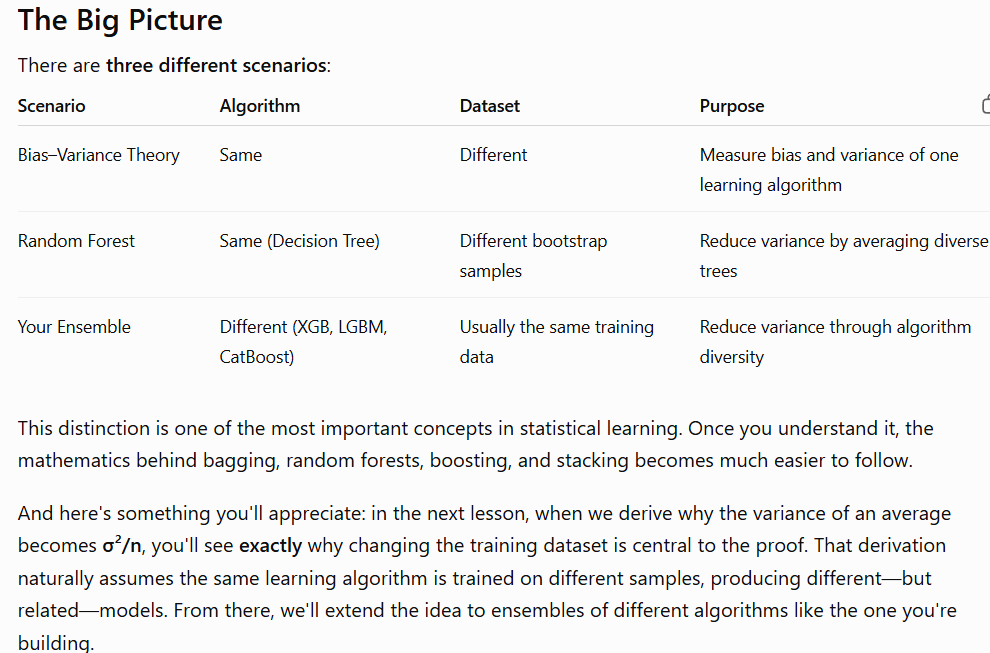

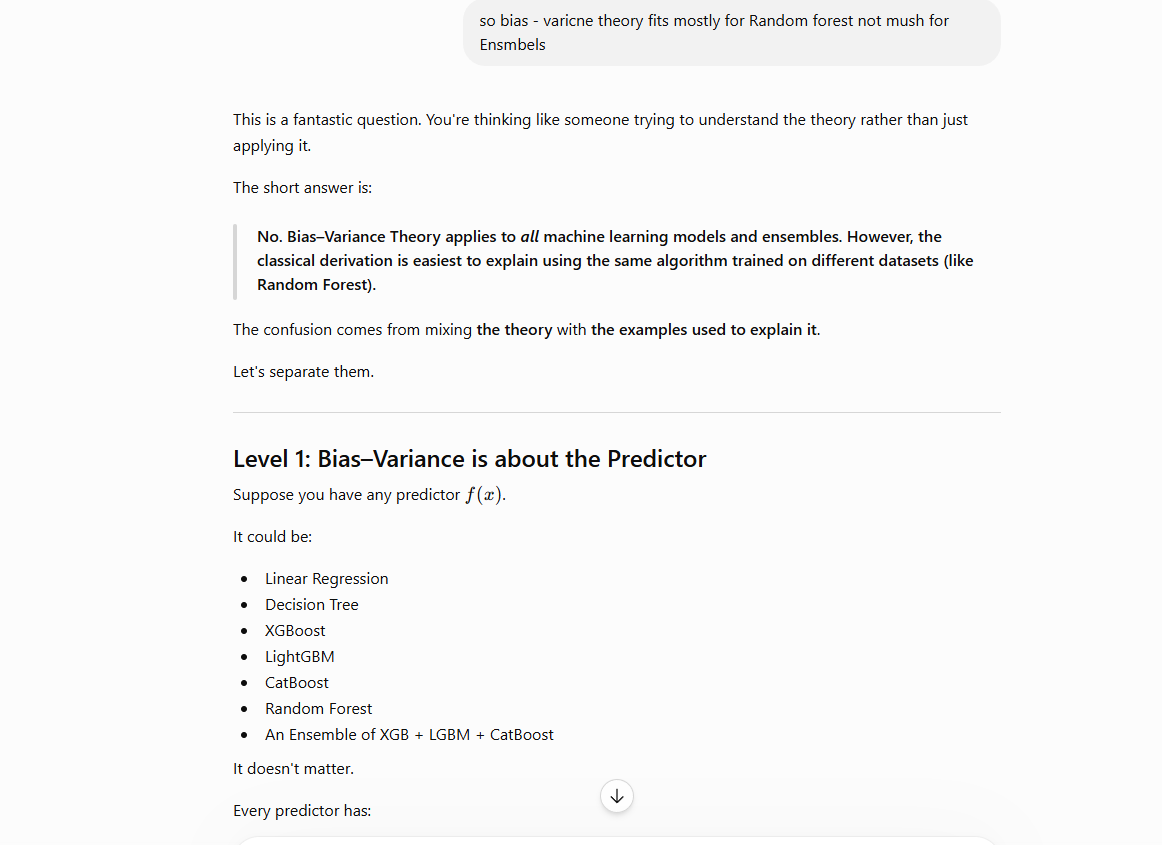
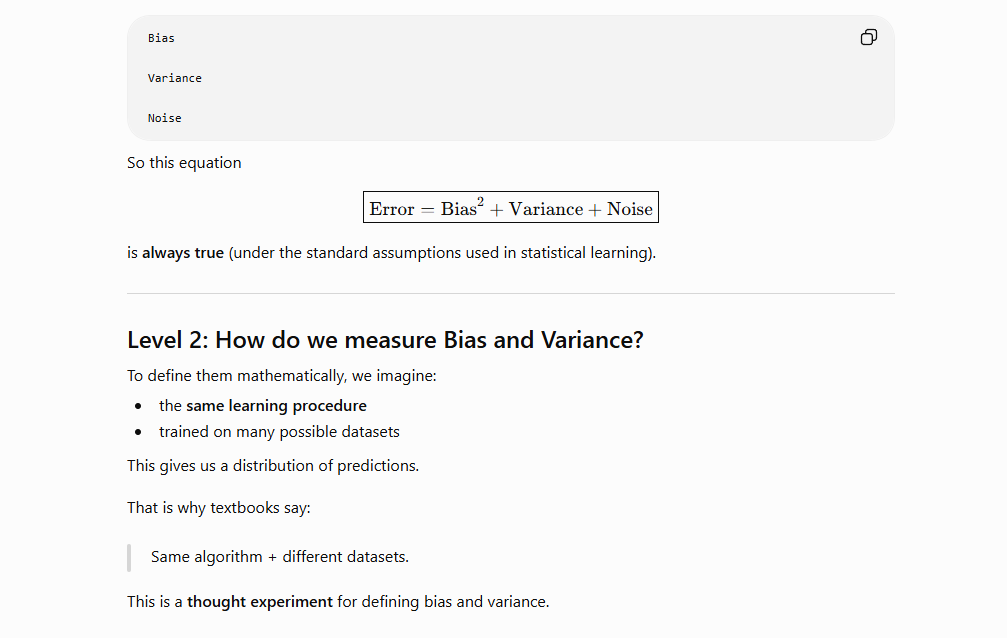
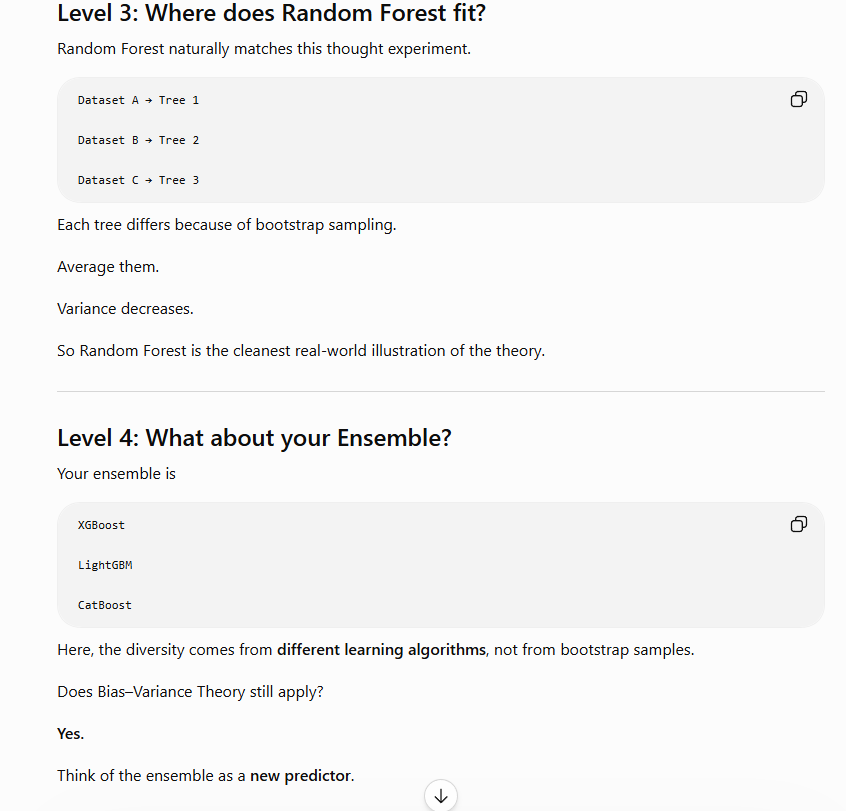
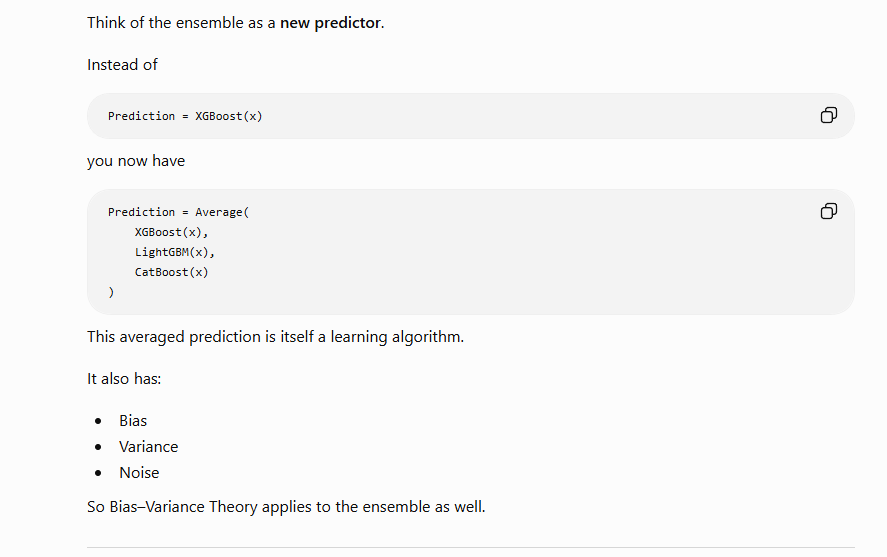
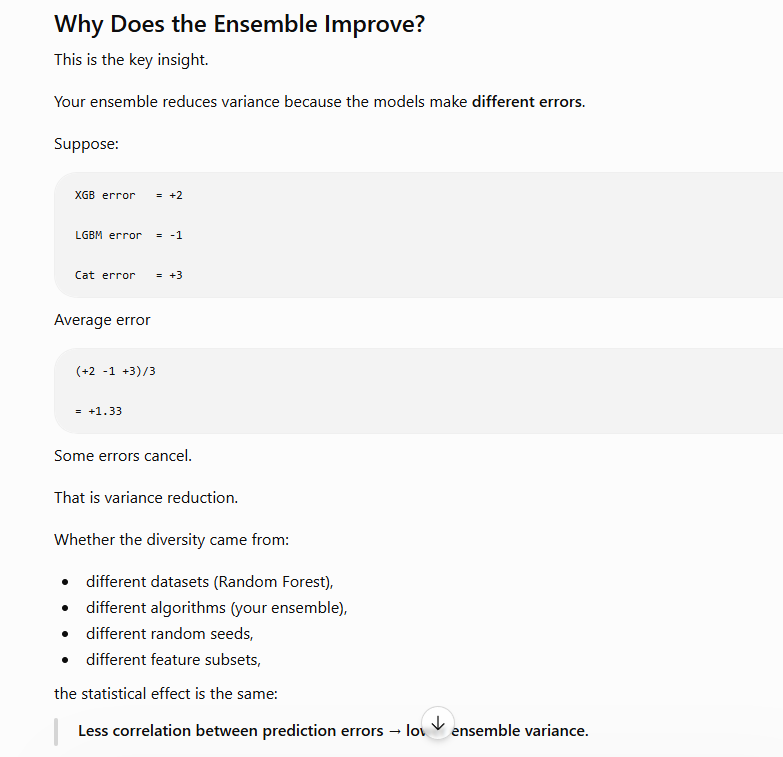
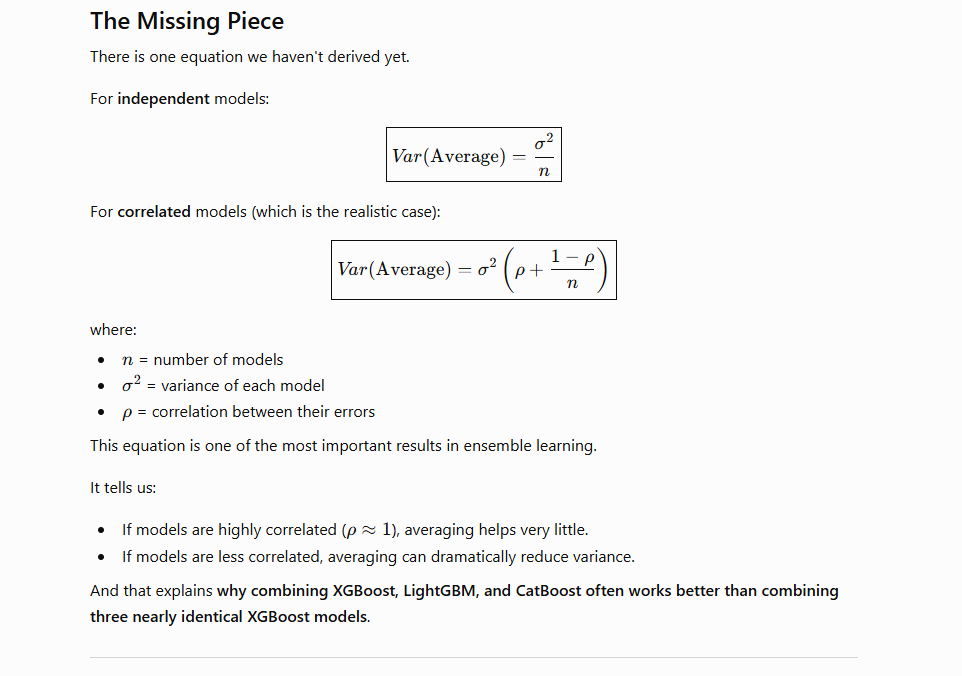
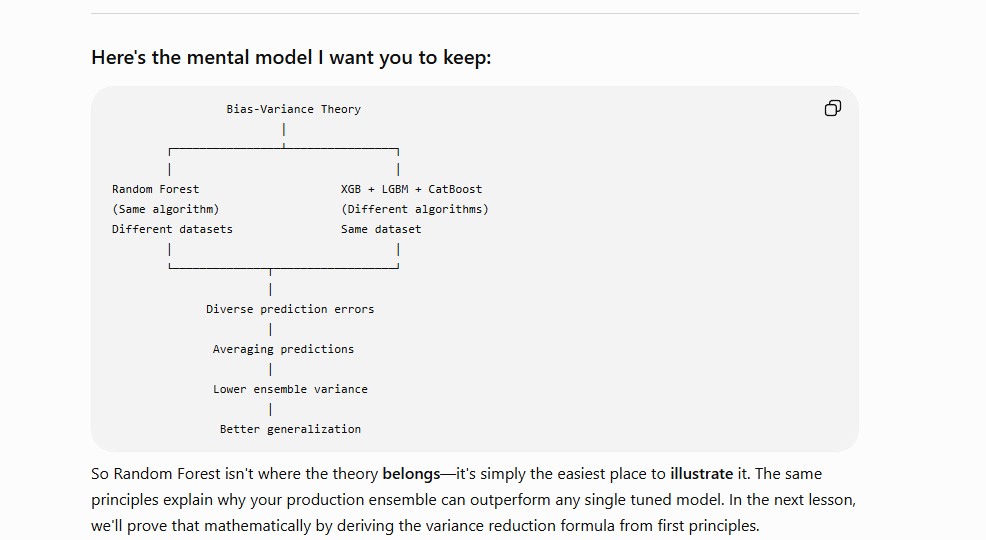

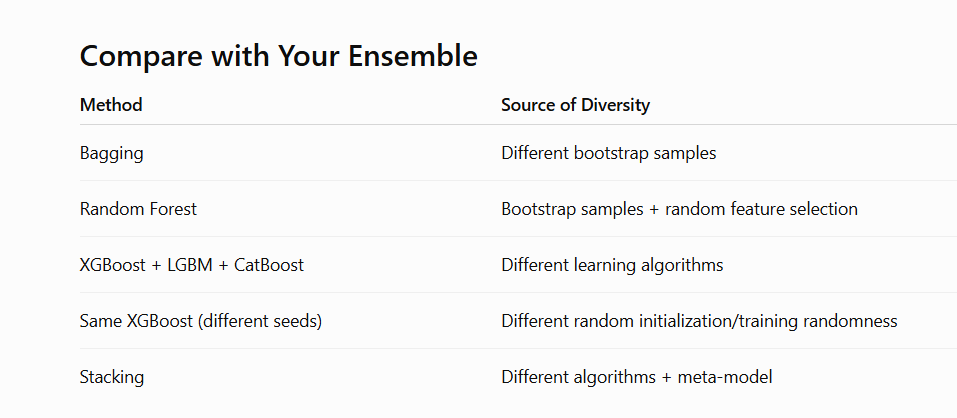
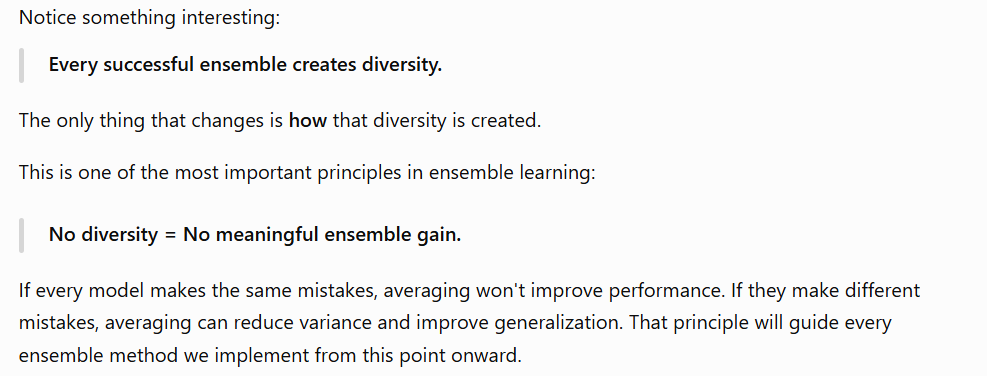

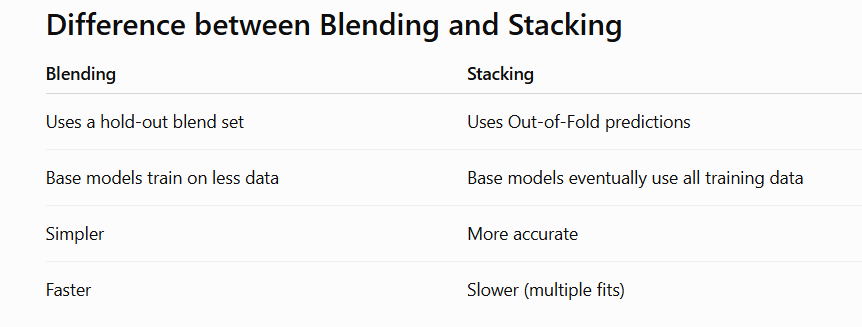

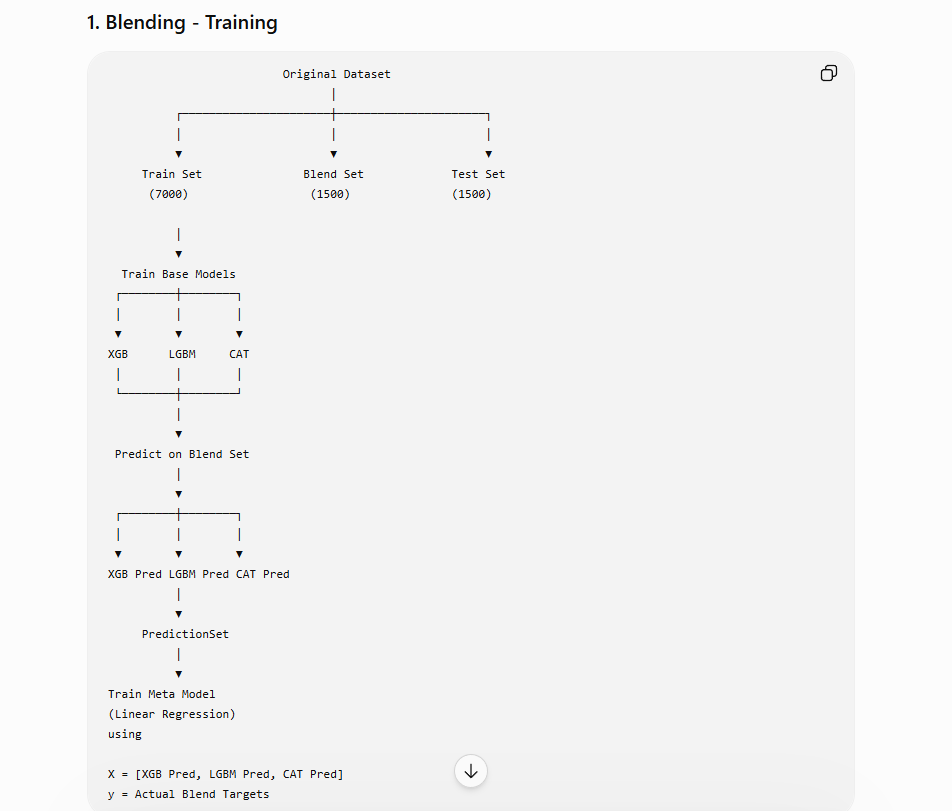
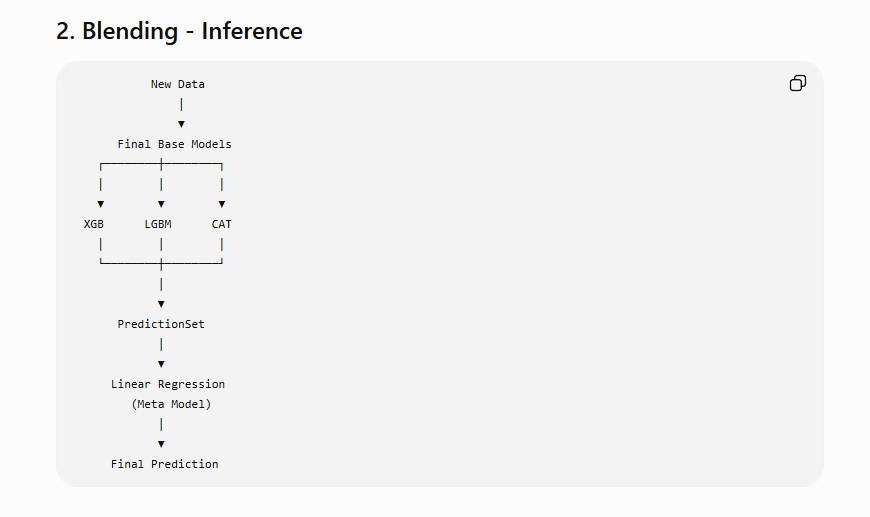
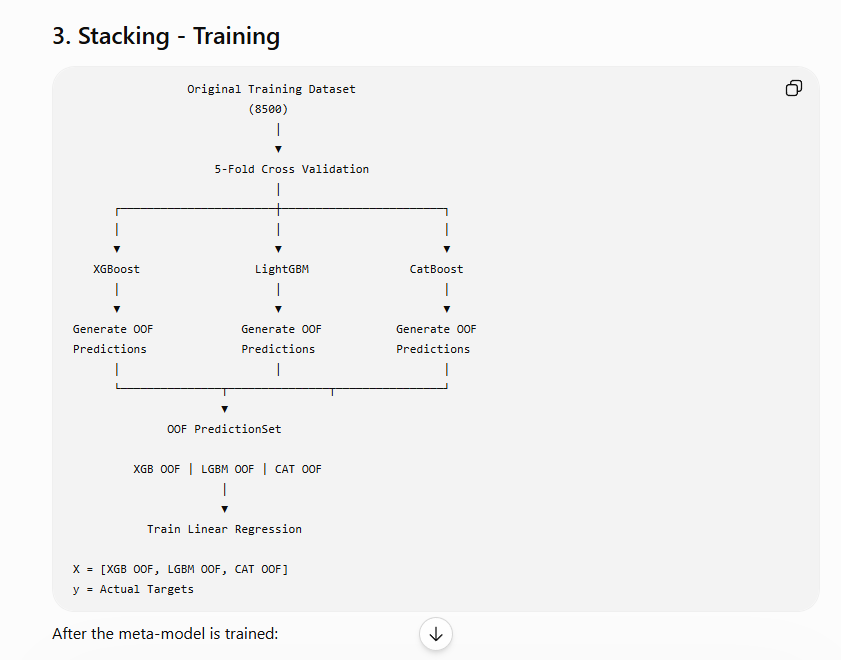
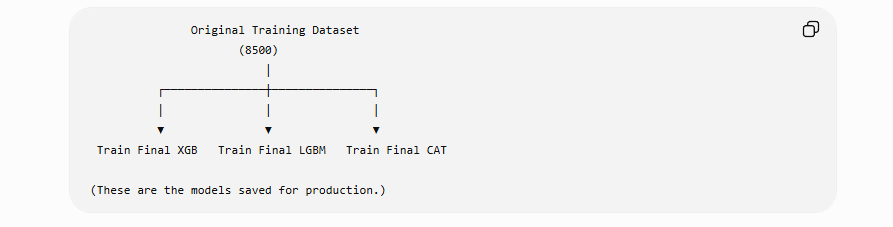
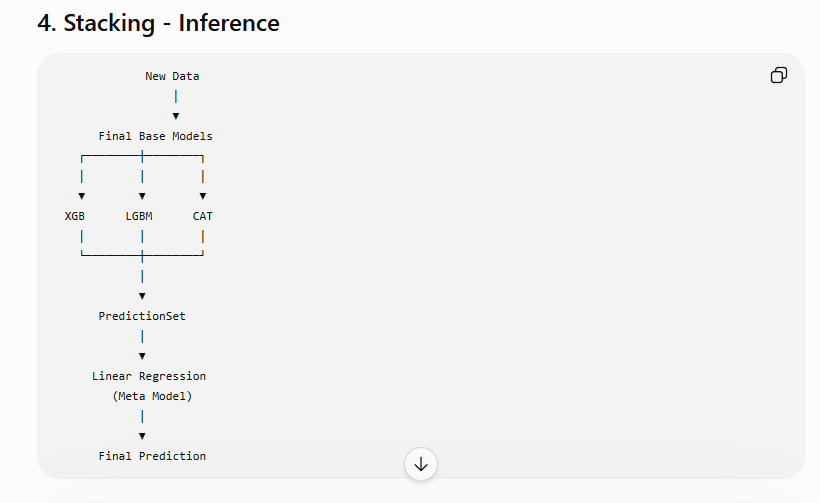
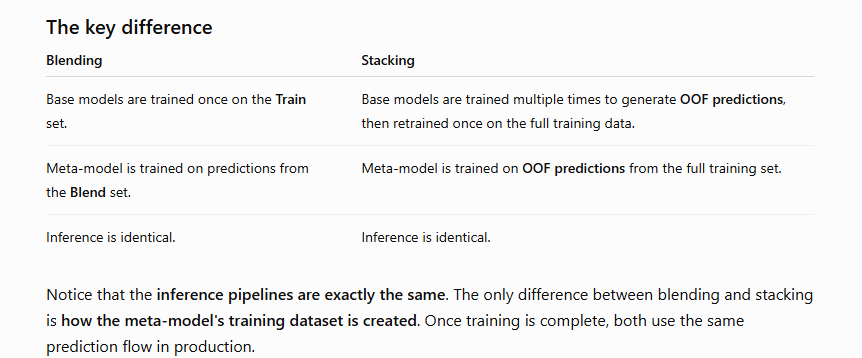
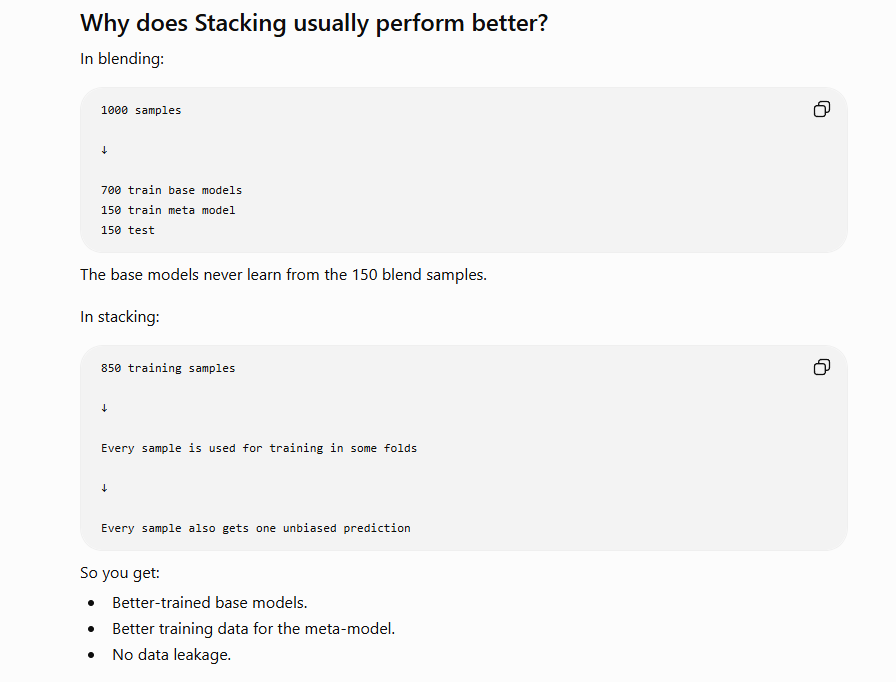

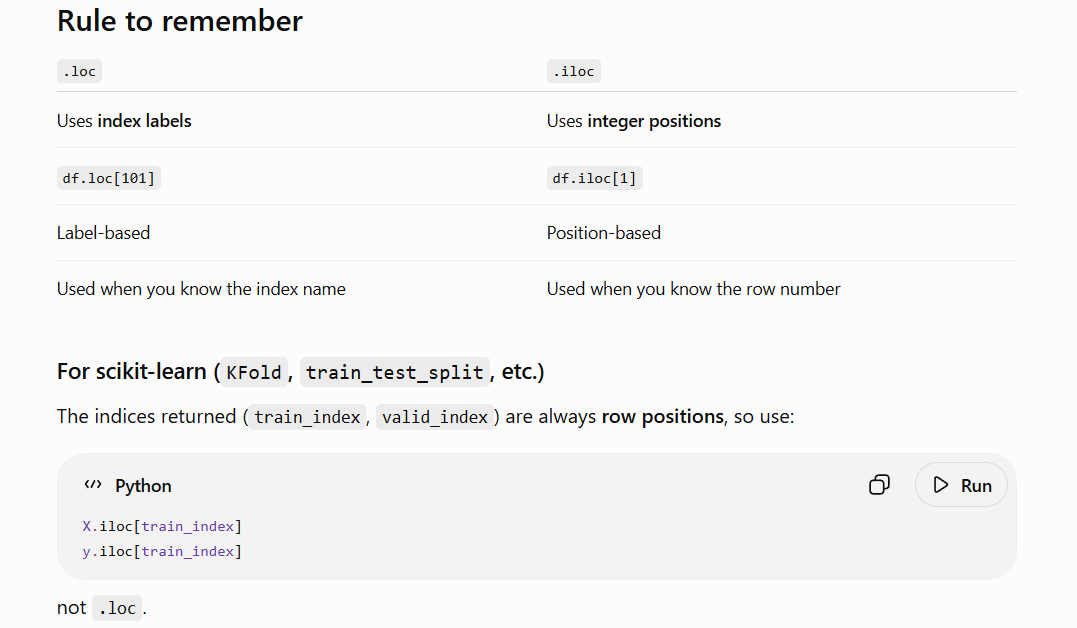

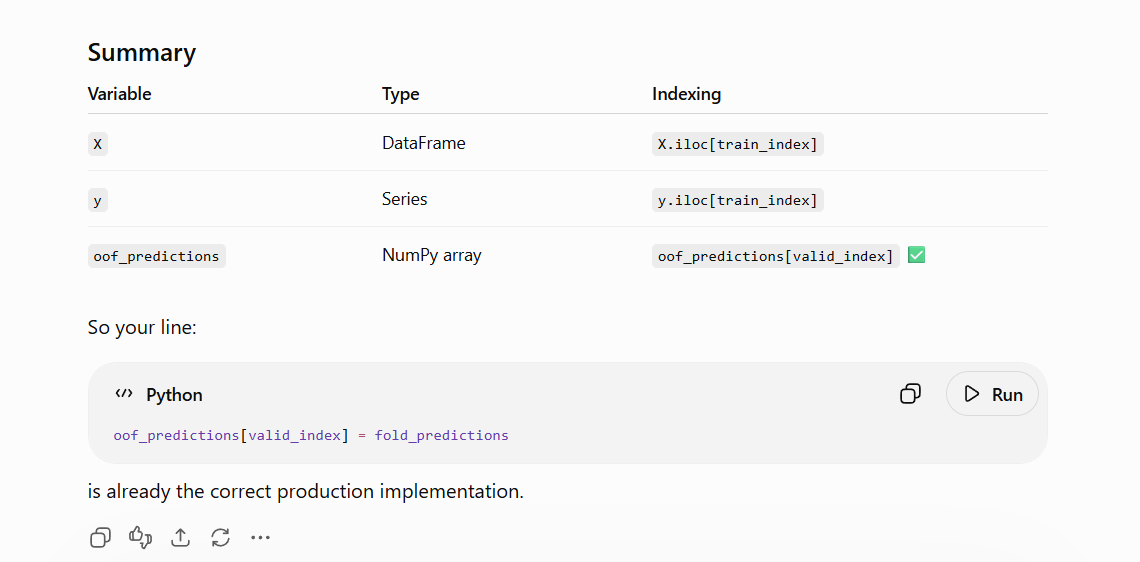

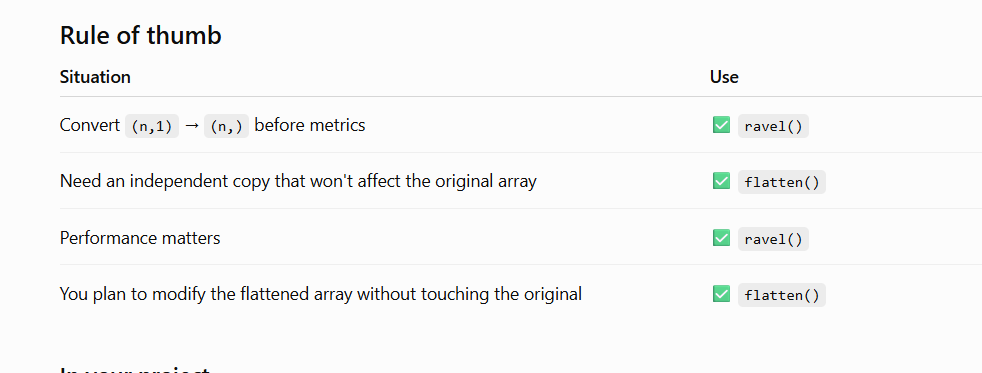

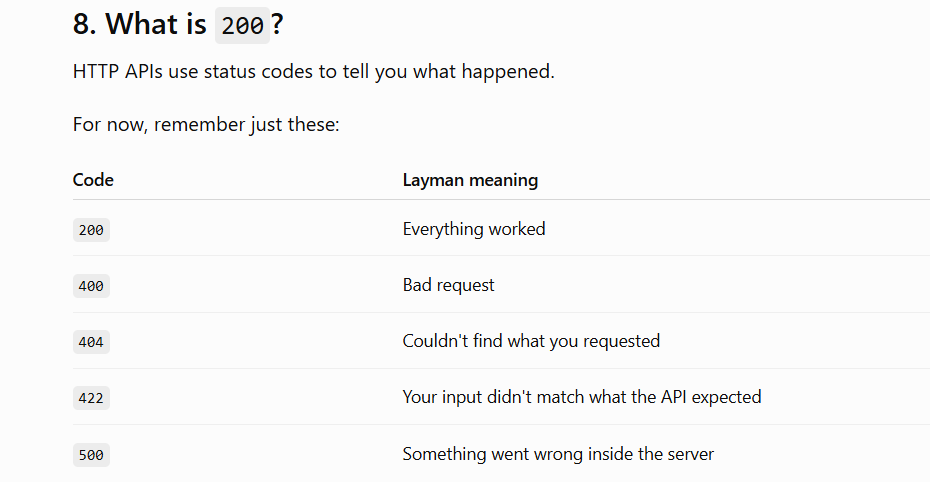

# Prometheus

Prometheus + PromQL Cheat Sheet
1. Counter — total requests

Python:

request_counter = Counter(
    "requests_total",
    "Total number of requests"
)

Increment:

request_counter.inc()

PromQL:

requests_total

Meaning: Current cumulative number of requests.

2. Counter with labels

Python:

request_counter = Counter(
    "requests_total",
    "Total number of requests",
    ["status"]
)

Increment:

request_counter.labels(status="success").inc()

or:

request_counter.labels(status="error").inc()

PromQL:

requests_total{status="success"}
requests_total{status="error"}

Meaning: Filter a metric by a label.

3. rate() — requests per second
rate(requests_total[5m])

Meaning:

Average per-second increase in the Counter over the last 5 minutes.

For your project:

rate(forecast_requests_total[5m])

This gives your forecast request rate.

4. Error request rate
rate(
  forecast_requests_total{status="error"}[5m]
)

Meaning:

Number of errors occurring per second over the last 5 minutes.

5. Success request rate
rate(
  forecast_requests_total{status="success"}[5m]
)
6. Error percentage

This is one of the most useful formulas.

(
  rate(forecast_requests_total{status="error"}[5m])
  /
  rate(forecast_requests_total[5m])
) * 100
Formula conceptually:
Error Rate %


       Error Requests
--------------------------- × 100
       Total Requests

Example:

10 errors
100 total requests


= 10 / 100 × 100
= 10%
7. Histogram

Python:

request_duration = Histogram(
    "request_duration_seconds",
    "Request processing time"
)

Record duration:

request_duration.observe(duration)

or:

with request_duration.time():
    ...

Prometheus creates:

request_duration_seconds_bucket
request_duration_seconds_count
request_duration_seconds_sum
8. Histogram _count
forecast_request_duration_seconds_count

Meaning:

Number of observations recorded by the Histogram.

For your project:

_count = 10

means:

10 forecast request durations were recorded.

9. Histogram _sum
forecast_request_duration_seconds_sum

Meaning:

Total duration of all recorded requests.

Example:

_count = 5
_sum = 100

means:

5 requests
100 seconds total
10. Average latency

This is one of the most reusable formulas.

forecast_request_duration_seconds_sum
/
forecast_request_duration_seconds_count

Conceptually:

Average Latency = Total Request Duration
                  ------------------------
                  Number of Requests

Example:

100 seconds / 5 requests
= 20 seconds
11. Average latency using rate()

For a continuously running production system, you'll commonly use:

rate(forecast_request_duration_seconds_sum[5m])
/
rate(forecast_request_duration_seconds_count[5m])

This gives the average request duration over the last 5 minutes.

This is generally more useful for a dashboard than lifetime _sum / _count.

12. Histogram buckets
forecast_request_duration_seconds_bucket

You'll see:

le="5"
le="10"
le="30"
le="60"
le="90"
le="120"
...
le="+Inf"

le means:

less than or equal to

So:

le="60" → number of requests ≤ 60 seconds
13. +Inf
le="+Inf"

means:

No upper limit.

Every recorded observation belongs to this bucket.

So if you have 100 requests:

+Inf = 100
14. histogram_quantile() — p95

This is the formula you just used:

histogram_quantile(
  0.95,
  rate(forecast_request_duration_seconds_bucket[5m])
)

Meaning:

Estimate the 95th percentile latency over the last 5 minutes.

In plain English:

Approximately 95% of requests complete within this duration.

15. p99
histogram_quantile(
  0.99,
  rate(forecast_request_duration_seconds_bucket[5m])
)

Meaning:

Estimate the 99th percentile latency.

16. p50 / Median
histogram_quantile(
  0.50,
  rate(forecast_request_duration_seconds_bucket[5m])
)

This is approximately the median latency.

So:

p50 → 50% of requests
p95 → 95% of requests
p99 → 99% of requests
17. rate() vs Counter

Remember this distinction:

Counter
forecast_requests_total

Answers:

How many requests have happened?

Rate
rate(forecast_requests_total[5m])

Answers:

How quickly are requests happening?

Example:

Counter = 10,000 requests
Rate = 2 requests/second

These are completely different measurements.

18. up — target health
up

You'll typically see:

up{job="demand-forecasting-api"} 1

Meaning:

1 → Prometheus successfully scraped the target
0 → Prometheus could not scrape the target

This is extremely useful for monitoring whether your application is reachable by Prometheus.

19. Filter by labels

General syntax:

metric_name{label="value"}

Example:

forecast_requests_total{status="error"}

Multiple labels:

forecast_requests_total{
    status="error",
    environment="production"
}
20. Sum across series

Suppose you have:

requests_total{status="success"} 80
requests_total{status="error"} 20

You can calculate:

sum(requests_total)

Result:

100
21. Sum by label

For example:

sum by (status) (
  rate(forecast_requests_total[5m])
)

This gives request rate separated by:

success
error

This becomes particularly useful when you have many instances.

22. increase() — how much did a Counter increase?

Another useful function:

increase(forecast_requests_total[1h])

Meaning:

How many requests were added during the last hour?

This differs from:

rate(...)

because:

increase() → number of events
rate()     → events per second

Example:

increase = 360

means:

360 requests occurred during that hour.

Your reusable formulas

If you want to save only the most important formulas, save these:

# Total requests
forecast_requests_total
# Request rate
rate(forecast_requests_total[5m])
# Error rate
rate(forecast_requests_total{status="error"}[5m])
# Error percentage
(
  rate(forecast_requests_total{status="error"}[5m])
  /
  rate(forecast_requests_total[5m])
) * 100
# Average latency
forecast_request_duration_seconds_sum
/
forecast_request_duration_seconds_count
# Average latency - last 5 minutes
rate(forecast_request_duration_seconds_sum[5m])
/
rate(forecast_request_duration_seconds_count[5m])
# p50
histogram_quantile(
  0.50,
  rate(forecast_request_duration_seconds_bucket[5m])
)
# p95
histogram_quantile(
  0.95,
  rate(forecast_request_duration_seconds_bucket[5m])
)
# p99
histogram_quantile(
  0.99,
  rate(forecast_request_duration_seconds_bucket[5m])
)
# Requests in the last hour
increase(forecast_requests_total[1h])
# Target health
up
The mental model to remember
COUNTER
   │
   ├── metric              → total
   ├── rate(metric[5m])    → per-second rate
   └── increase(metric[1h])→ total increase


HISTOGRAM
   │
   ├── _count              → number of observations
   ├── _sum                → total duration
   ├── _bucket             → distribution
   │
   ├── _sum / _count       → average
   │
   └── histogram_quantile()
          ├── 0.50         → p50
          ├── 0.95         → p95
          └── 0.99         → p99

This is the core PromQL toolkit you'll reuse across your other ML/AI APIs.

A few advanced topics remain

We can learn these after Grafana, rather than getting stuck in Prometheus:

Gauges — CPU/memory/current values
More useful labels — endpoint, model version, HTTP status
Recording rules — precompute expensive PromQL
Alerting — "notify me when error rate > 5%"
Alertmanager — actually deliver alerts
Prometheus service discovery — important when you have many services
Production considerations — retention, scaling, federation

For your learning goal, I wouldn't do all of those now.

1. Why does AWS need your public IP?

AWS doesn't really need to know your IP personally. We are giving AWS your public IP to create a firewall rule.

Remember our Security Group?

Internet
   │
   │
   ▼
┌───────────────┐
│ Security Group│
│               │
│ Who is allowed│
│ to connect?   │
└───────┬───────┘
        │
        ▼
       EC2

When we create the EC2, we want to connect to it from your laptop.

But your laptop is behind your home/office router.

Your laptop might have an internal address like:

192.168.1.25

That address is private. AWS cannot use it to identify your connection over the internet.

Your internet connection has a public address:

49.206.133.86

So we tell the AWS Security Group:

Allow SSH connections coming from 49.206.133.86.

Then the firewall rule becomes:

Port:     22
Protocol: TCP
Source:   49.206.133.86/32
Action:   ALLOW

The /32 means:

Exactly one IP address.

2. What is SSH?

SSH means:

Secure Shell

It is a protocol that lets you remotely log into another computer and control it using a terminal.

For example, your computer is:

Your Windows laptop

and the EC2 will be:

Linux server

SSH allows you to do:

Your laptop
     │
     │ SSH
     ▼
AWS EC2

Once connected, you'll see something like:

ubuntu@ip-172-31-5-42:~$

And then you can execute commands on the EC2:

docker ps
docker images
docker compose up -d
ls
cd production_deployment

It's basically like opening a terminal on the EC2 from your own laptop.

3. Why is SSH on port 22?

Network services listen on ports.

SSH conventionally uses:

TCP port 22

So when you connect:

EC2_PUBLIC_IP:22

you're saying:

"I want to establish an SSH connection."

For example:

Your laptop
49.206.133.86
       │
       │ TCP 22
       ▼
EC2

The Security Group decides whether that connection is allowed.

4. Why not allow everybody?

We could create:

Port 22
Source: 0.0.0.0/0

That means:

Anybody on the internet can attempt to SSH into my EC2.

That's a bad idea.

Instead:

Port 22
Source: 49.206.133.86/32

means:

Only a connection coming from my current public IP can reach SSH.

So:

                    EC2
                     │
               Security Group
                     │
              TCP port 22
                     │
          ┌──────────┴──────────┐
          │                     │
49.206.133.86              8.8.8.8
     │                         │
     ▼                         ▼
   ALLOW                    BLOCK
5. One important thing to understand

Your public IP:

49.206.133.86

belongs to your internet connection, not necessarily your individual laptop.

For example:

Laptop
192.168.1.20
     │
     ▼
Wi-Fi Router
     │
     ▼
Internet
     │
     ▼
49.206.133.86
     │
     ▼
AWS

So AWS sees the public IP of your network connection.

If your ISP changes your public IP tomorrow, the rule:

49.206.133.86/32

will no longer match your new IP.

That's why you might occasionally need to update the SSH Security Group rule.

The big picture

We're setting up this:

                 INTERNET
                    │
                    │
             Your public IP
            49.206.133.86
                    │
                    │ SSH :22
                    ▼
          ┌─────────────────┐
          │ Security Group  │
          │                 │
          │ 22 → YOUR IP    │
          │ 3000 → later    │
          │ 8000 → later    │
          │ 9090 → blocked  │
          └────────┬────────┘
                   │
                   ▼
                 EC2
                   │
            ┌──────┼──────┐
            ▼      ▼      ▼
           API    Prom   Grafana
          :8000   :9090   :3000

So AWS doesn't need your public IP for EC2 itself. We're using it to tell the EC2 firewall (Security Group) exactly which internet connection is allowed to SSH into the server.

And this is why we're checking your IP before creating the SSH rule.

AWS ec2 machine root structure

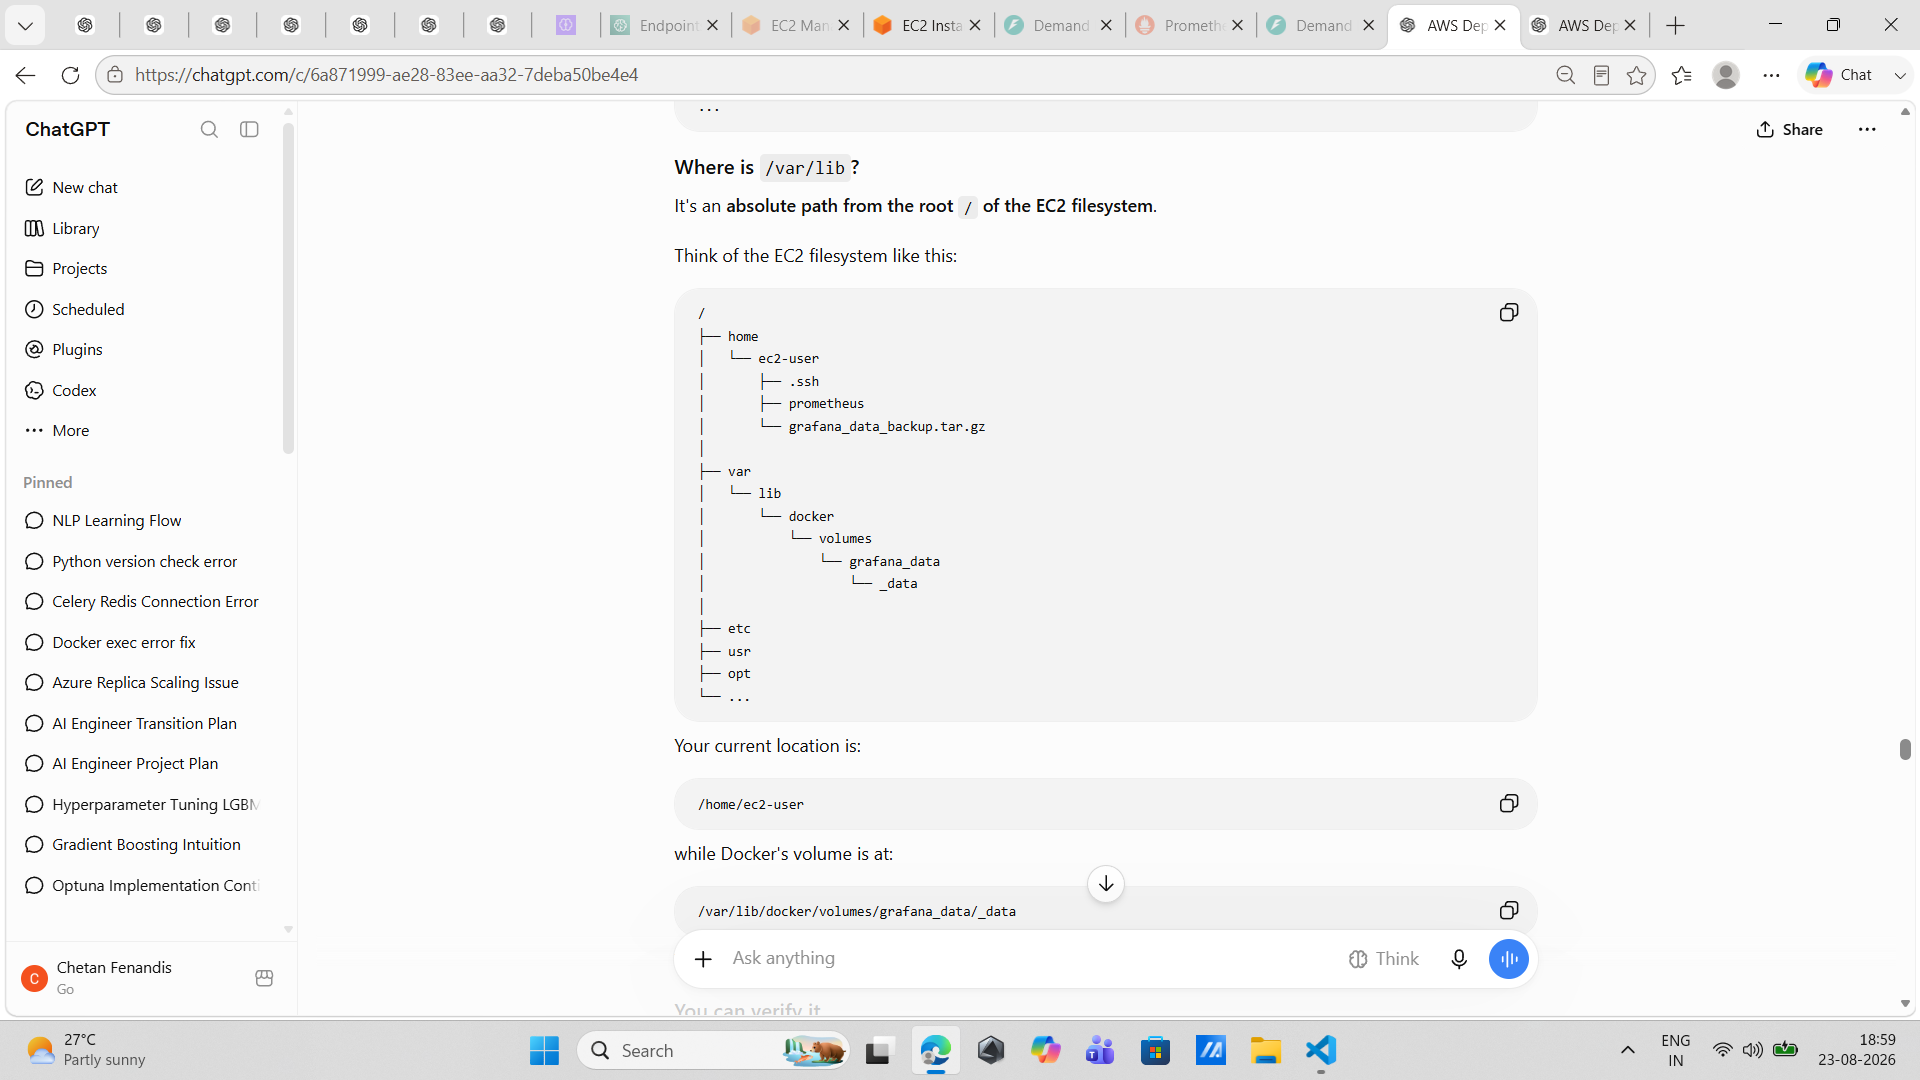